In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
%pip install scipy
%pip install seaborn
import torch as t
device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

## Generate plot for: 1) Stability gap between the most- and least-stable layers

In [ ]:
SCRATCH = "Path to root directory"
df_dir_avg_sim = SCRATCH + "df/avg_sim/"

results = []

def get_df_info(df_dir):
    df_files = [f for f in os.listdir(df_dir) if os.path.isfile(os.path.join(df_dir, f))]
    df_info = []
    for fname in df_files:
        try:
            n_layers = int(fname.split("_l")[1].split("_")[0])
        except Exception:
            n_layers = None
        try:
            n_heads = int(fname.split("_h")[1].split("_")[0])
        except Exception:
            n_heads = None
        try:
            #epoch = int(fname.split("_epoch")[1].split("_")[0])
            epoch = 1
        except Exception:
            epoch = None
        wd = "_wd" in fname
        attn_only = "_attn" in fname
        df_info.append({
            "file": fname,
            "num_layers": n_layers,
            "num_heads": n_heads,
            "epoch": epoch,
            "attn_only": attn_only,
            "wd": wd,
        })
        print(f"Parsed {fname}: layers={n_layers}, heads={n_heads}, epoch={epoch}, attn_only={attn_only}")
    # Only keep files with epoch == 1 or 9
    df_info = [info for info in df_info if info["epoch"] in (1, 9)]
    df_files = [info["file"] for info in df_info]
    return df_files, df_info

dirs = {
    "avg_head_similarity": df_dir_avg_sim,
}

for name, df_dir in dirs.items():
    print(f"\n{name.upper()} directory: {df_dir}")
    df_files, df_info = get_df_info(df_dir)
    
    df_info_sorted = sorted(df_info, key=lambda x: (x['num_layers'] if x['num_layers'] is not None else 0, 
                                                    x['num_heads'] if x['num_heads'] is not None else 0))
    print("Files (sorted):", [info['file'] for info in df_info_sorted])
    for info in df_info_sorted:
        print(info)
    for info in df_info_sorted:
        file = info['file']
        file_path = os.path.join(df_dir, file)
        try:
            df_loaded = pd.read_pickle(file_path)
            # Filter rows where anchor==1 or inst_1==1
            if "anchor_idx" in df_loaded.columns:
                df_loaded = df_loaded[df_loaded["anchor_idx"] == 0]
            elif "inst_1" in df_loaded.columns:
                df_loaded = df_loaded[df_loaded["inst_1"] == 0]
            print(f"\nLoaded {file}:")
            print(df_loaded.head())
            if df_dir == df_dir_avg_sim:
                # New format uses 'cos_sim' column
                if 'layer' in df_loaded.columns and 'cos_sim' in df_loaded.columns:
                    df_plot = df_loaded.groupby('layer')['cos_sim'].mean().reset_index()
                    df_plot['layer'] = df_plot['layer'].astype(int)  # layer already 1-indexed in the new format
                    # Calculate largest drop
                    sim_diff = df_plot['cos_sim'].diff()
                    min_drop_idx = sim_diff.idxmin()
                    if min_drop_idx > 0:
                        drop_layer = int(df_plot.loc[min_drop_idx, 'layer'])
                        drop_value = float(sim_diff.loc[min_drop_idx])
                    else:
                        drop_layer = None
                        drop_value = None
                    min_idx = df_plot['cos_sim'].idxmin()
                    min_layer = int(df_plot.loc[min_idx, 'layer'])
                    min_value = float(df_plot.loc[min_idx, 'cos_sim'])
                    max_idx = df_plot['cos_sim'].idxmax()
                    max_layer = int(df_plot.loc[max_idx, 'layer'])
                    max_value = float(df_plot.loc[max_idx, 'cos_sim'])
                    results.append({**info, "min_layer": min_layer, "min_value": min_value,
                                    "max_layer": max_layer, "max_value": max_value, "type": name,
                                    "largest_drop_layer": drop_layer, "largest_drop_value": drop_value})
                    # plt.figure()
                    # plt.plot(df_plot['layer'], df_plot['cos_sim'], marker='o')
                    # plt.scatter([min_layer], [min_value], color='red', label=f'Min: Layer {min_layer}')
                    # plt.scatter([max_layer], [max_value], color='green', label=f'Max: Layer {max_layer}')
                    # plt.title(f"{name.upper()} - Mean Cosine Similarity by Layer ({file})")
                    # plt.xlabel("Layer")
                    # plt.ylabel("Mean Cosine Similarity")
                    # plt.ylim(0, 1)
                    # plt.legend()
                    # plt.show()
            else:
                if 'layer' in df_loaded.columns and 'cka_sim' in df_loaded.columns:
                    df_plot = df_loaded.groupby('layer')['cka_sim'].mean().reset_index()
                    df_plot['layer'] = df_plot['layer'].astype(int) + 1
                    # Calculate largest drop
                    sim_diff = df_plot['cka_sim'].diff()
                    min_drop_idx = sim_diff.idxmin()
                    if min_drop_idx > 0:
                        drop_layer = int(df_plot.loc[min_drop_idx, 'layer'])
                        drop_value = float(sim_diff.loc[min_drop_idx])
                    else:
                        drop_layer = None
                        drop_value = None
                    min_idx = df_plot['cka_sim'].idxmin()
                    min_layer = df_plot.loc[min_idx, 'layer']
                    min_value = df_plot.loc[min_idx, 'cka_sim']
                    max_idx = df_plot['cka_sim'].idxmax()
                    max_layer = df_plot.loc[max_idx, 'layer']
                    max_value = df_plot.loc[max_idx, 'cka_sim']
                    results.append({**info, "min_layer": min_layer, "min_value": min_value,
                                    "max_layer": max_layer, "max_value": max_value, "type": name,
                                    "largest_drop_layer": drop_layer, "largest_drop_value": drop_value})
                    # plt.figure()
                    # plt.plot(df_plot['layer'], df_plot['cka_sim'], marker='o')
                    # plt.scatter([min_layer], [min_value], color='red', label=f'Min: Layer {min_layer}')
                    # plt.scatter([max_layer], [max_value], color='green', label=f'Max: Layer {max_layer}')
                    # plt.title(f"{name.upper()} - Mean CKA Similarity by Layer ({file})")
                    # plt.xlabel("Layer")
                    # plt.ylabel("Mean CKA Similarity")
                    # plt.ylim(0, 1)
                    # plt.legend()
                    # plt.show()
        except Exception as e:
            print(f"Failed to load or plot {file}: {e}")

df_minmax_layer = pd.DataFrame(results)

In [3]:
df_minmax_layer['min_length_ratio'] = df_minmax_layer['min_layer'] / df_minmax_layer['num_layers']
df_minmax_layer['max_length_ratio'] = df_minmax_layer['max_layer'] / df_minmax_layer['num_layers']
df_minmax_layer

,file,num_layers,num_heads,epoch,attn_only,wd,min_layer,min_value,max_layer,max_value,type,largest_drop_layer,largest_drop_value,min_length_ratio,max_length_ratio
0,df_avg_sim_l2_h8_epoch1.pkl,2,8,1,False,False,2,0.837471,1,0.969305,avg_head_similarity,2,-0.131834,1.000000,0.500000
1,df_avg_sim_l2_h8_attn_epoch1.pkl,2,8,1,True,False,2,0.769432,1,0.817126,avg_head_similarity,2,-0.047693,1.000000,0.500000
2,df_avg_sim_l2_h8_wd_epoch1.pkl,2,8,1,False,True,2,0.841874,1,0.962640,avg_head_similarity,2,-0.120766,1.000000,0.500000
3,df_avg_sim_l2_h8_attn_wd_epoch1.pkl,2,8,1,True,True,2,0.838557,1,0.943963,avg_head_similarity,2,-0.105406,1.000000,0.500000
4,df_avg_sim_l2_h16_epoch1.pkl,2,16,1,False,False,2,0.869426,1,0.900477,avg_head_similarity,2,-0.031052,1.000000,0.500000
5,df_avg_sim_l2_h16_wd_epoch1.pkl,2,16,1,False,True,2,0.860413,1,0.956824,avg_head_similarity,2,-0.096411,1.000000,0.500000
6,df_avg_sim_l2_h16_attn_epoch1.pkl,2,16,1,True,False,1,0.776865,2,0.778068,avg_head_similarity,2,0.001204,0.500000,1.000000
7,df_avg_sim_l2_h16_attn_wd_epoch1.pkl,2,16,1,True,True,2,0.816980,1,0.910049,avg_head_similarity,2,-0.093069,1.000000,0.500000
8,df_avg_sim_l4_h8_epoch1.pkl,4,8,1,False,False,3,0.808852,1,0.984123,avg_head_similarity,2,-0.088384,0.750000,0.250000
9,df_avg_sim_l4_h8_wd_epoch1.pkl,4,8,1,False,True,3,0.816417,1,0.979324,avg_head_similarity,2,-0.092468,0.750000,0.250000


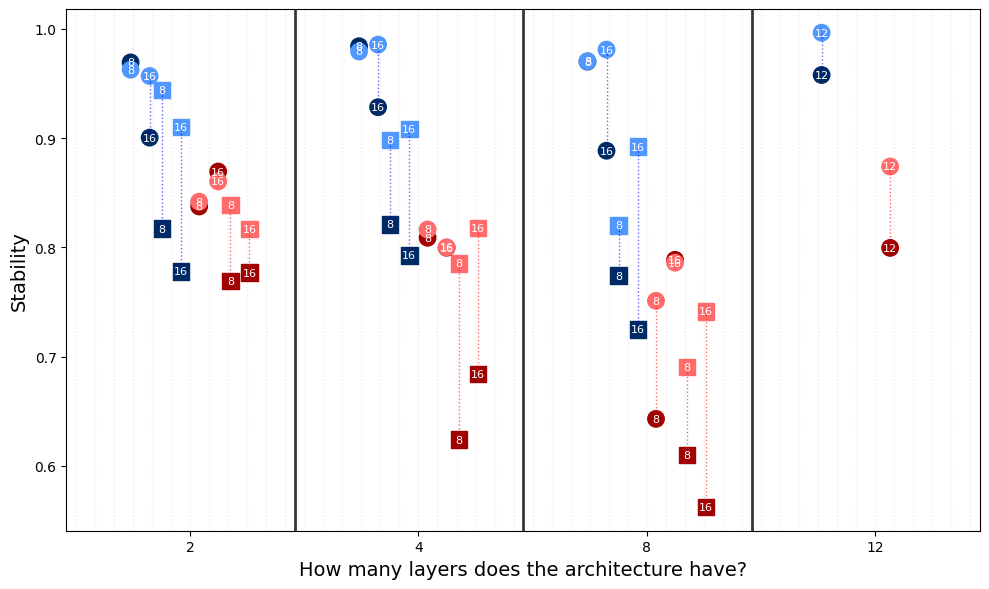

In [23]:
from matplotlib.lines import Line2D

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

def lighten_color(color, amount=0.5):
    try:
        c = mcolors.cnames[color]
    except Exception:
        c = color
    c = mcolors.to_rgb(c)
    return mcolors.to_hex([min(1, x + (1 - x) * amount) for x in c])

def darken_color(color, amount=0.3):
    try:
        c = mcolors.cnames[color]
    except Exception:
        c = color
    c = mcolors.to_rgb(c)
    return mcolors.to_hex([max(0, x * (1 - x)) for x in c])

# Explicit dark/light color choices
DARK_BLUE = "#002a64"
LIGHT_BLUE = "#5098fd"
DARK_RED = "#a00101"
LIGHT_RED = "#ff6a6a"

def get_shaded_color(color, wd):
    # color expected to be 'blue' or 'red' in this script
    c = color.lower()
    if c == 'blue':
        return LIGHT_BLUE if wd else DARK_BLUE
    if c == 'red':
        return LIGHT_RED if wd else DARK_RED
    # fallback to original behavior for other color names/hex values
    return lighten_color(color, amount=0.4) if wd else darken_color(color, amount=0.5)

# attn_only -> square, mlp -> circle
marker_shape_map = {True: 's', False: 'o'}
marker_displacement_shape = {'o': -0.01, 's': 0.01}

allowed_layers = [2, 4, 8, 12]

# Divide x-axis into 48 grid lines, 12 per layer
total_grid_lines = 48
segment_width = total_grid_lines // len(allowed_layers)  # 12
layer_positions = {layer: i * segment_width + segment_width / 2 for i, layer in enumerate(allowed_layers)}  # centers: 6,18,30,42

subset = df_minmax_layer[df_minmax_layer['type'] == 'avg_head_similarity']

vertical_jitter_value = 0.000  # kept but no longer used for vertical separation

# Build per-layer ordering of (num_heads, attn_only) combos so we can spread them horizontally
layer_group_map = {}
layer_group_counts = {}
for layer in allowed_layers:
    lg = (
        subset[subset['num_layers'] == layer][['num_heads', 'attn_only']]
        .drop_duplicates()
        .sort_values(['num_heads', 'attn_only'])
        .reset_index(drop=True)
    )
    mapping = {}
    for idx, row in lg.iterrows():
        mapping[(int(row['num_heads']), bool(row['attn_only']))] = int(idx)
    layer_group_map[layer] = mapping
    layer_group_counts[layer] = len(lg)

# Increased marker size
marker_size = 140  # increased from 80

# legend handles for shapes (num inside indicates num_heads)
shape_handles = [
    Line2D([0], [0], marker='o', color='grey', linestyle='None', markersize=10, label='MLP (num=heads)'),
    Line2D([0], [0], marker='s', color='grey', linestyle='None', markersize=10, label='Attn only (num=heads)')
]

fig1, ax1 = plt.subplots(1, 1, figsize=(10, 6))

# 48 vertical grid lines across the x-axis
for pos in range(total_grid_lines):
    ax1.axvline(pos, color='gray', linestyle=':', linewidth=1, alpha=0.15)

# Solid bold separators between the 12-unit segments (dividing the plot for options 2,4,8,12)
# draw at the boundaries between segments (i.e. between 0-11, 12-23, 24-35, 36-47 -> boundaries at 12,24,36)
for i in range(1, len(allowed_layers)):
    boundary_x = i * segment_width - 0.5  # place between integer gridlines
    ax1.axvline(boundary_x, color='#222222', linestyle='-', linewidth=2.0, alpha=0.9, zorder=3)

# Offset the x-centers so max_value and min_value markers use different centers per layer
center_offset = segment_width * 0.15  # tweak if you want more/less separation
layer_positions_max = {l: c - center_offset for l, c in layer_positions.items()}
layer_positions_min = {l: c + center_offset for l, c in layer_positions.items()}

# containers to connect wd pairs
max_points = {}
min_points = {}

# Increased spacing to maintain symmetry with larger markers
group_spacing = 1.4  # increased from 1.05

# plot all max (blue) points first using layer_positions_max
for num_heads in sorted(subset['num_heads'].unique()):
    for attn_only in [False, True]:
        sub_data = subset[(subset['num_heads'] == num_heads) & (subset['attn_only'] == attn_only)]
        if sub_data.empty:
            continue

        marker_shape = marker_shape_map[attn_only]
        displacement_scaled = marker_displacement_shape.get(marker_shape, 0) * segment_width

        # compute group indices and extra offsets so different (num_heads, attn_only) combos in the same layer don't overlap
        group_indices = [
            layer_group_map[int(l)].get((int(nh), bool(ao)), 0)
            for l, nh, ao in zip(sub_data['num_layers'], sub_data['num_heads'], sub_data['attn_only'])
        ]
        extra_offsets = []
        for l, gi in zip(sub_data['num_layers'], group_indices):
            count = max(1, layer_group_counts[int(l)])
            center_idx = (count - 1) / 2.0
            extra_offsets.append((gi - center_idx) * group_spacing)

        x_centers_max = sub_data['num_layers'].map(layer_positions_max)
        x_base_max = x_centers_max + displacement_scaled
        x_base_max = x_base_max + np.array(extra_offsets)  # apply per-row extra spacing

        wd_x_jitter = np.where(sub_data['num_heads'].values==8, 0.9, -0.9)  # increased from 0.7/-0.7
        x_vals_max = x_base_max + wd_x_jitter

        y_vals_max = sub_data['max_value'].values
        colors_max = [get_shaded_color('blue', wd) for wd in sub_data['wd']]

        ax1.scatter(x_vals_max, y_vals_max, s=marker_size, marker=marker_shape, color=colors_max)
        for xv, yv, lv, wd_val in zip(x_vals_max, y_vals_max, sub_data['num_layers'], sub_data['wd']):
            ax1.text(xv, yv, str(int(num_heads)), ha='center', va='center', fontsize=8, color='white')  # increased from 6
            max_points.setdefault((lv, num_heads, attn_only), []).append((wd_val, xv, yv))

# then plot all min (red) points using layer_positions_min
for num_heads in sorted(subset['num_heads'].unique()):
    for attn_only in [False, True]:
        sub_data = subset[(subset['num_heads'] == num_heads) & (subset['attn_only'] == attn_only)]
        if sub_data.empty:
            continue

        marker_shape = marker_shape_map[attn_only]
        displacement_scaled = marker_displacement_shape.get(marker_shape, 0) * segment_width

        # compute group indices and extra offsets so different (num_heads, attn_only) combos in the same layer don't overlap
        group_indices = [
            layer_group_map[int(l)].get((int(nh), bool(ao)), 0)
            for l, nh, ao in zip(sub_data['num_layers'], sub_data['num_heads'], sub_data['attn_only'])
        ]
        extra_offsets = []
        for l, gi in zip(sub_data['num_layers'], group_indices):
            count = max(1, layer_group_counts[int(l)])
            center_idx = (count - 1) / 2.0
            extra_offsets.append((gi - center_idx) * group_spacing)

        x_centers_min = sub_data['num_layers'].map(layer_positions_min)
        x_base_min = x_centers_min + displacement_scaled
        x_base_min = x_base_min + np.array(extra_offsets)  # apply per-row extra spacing

        wd_x_jitter = np.where(sub_data['num_heads'].values==8, 0.9, -0.9)  # increased from 0.7/-0.7
        x_vals_min = x_base_min + wd_x_jitter

        y_vals_min = sub_data['min_value'].values
        colors_min = [get_shaded_color('red', wd) for wd in sub_data['wd']]

        ax1.scatter(x_vals_min, y_vals_min, s=marker_size, marker=marker_shape, color=colors_min)
        for xv, yv, lv, wd_val in zip(x_vals_min, y_vals_min, sub_data['num_layers'], sub_data['wd']):
            ax1.text(xv, yv, str(int(num_heads)), ha='center', va='center', fontsize=8, color='white')  # increased from 6
            min_points.setdefault((lv, num_heads, attn_only), []).append((wd_val, xv, yv))

# connect wd pairs with dotted lines
for pts in max_points.values():
    if len(pts) == 2:
        pts_sorted = sorted(pts, key=lambda t: t[0])  # sort by wd
        ax1.plot([pts_sorted[0][1], pts_sorted[1][1]],
                 [pts_sorted[0][2], pts_sorted[1][2]],
                 linestyle=':', color='blue', alpha=0.6, linewidth=1)

for pts in min_points.values():
    if len(pts) == 2:
        pts_sorted = sorted(pts, key=lambda t: t[0])  # sort by wd
        ax1.plot([pts_sorted[0][1], pts_sorted[1][1]],
                 [pts_sorted[0][2], pts_sorted[1][2]],
                 linestyle=':', color='red', alpha=0.6, linewidth=1)


# Color legend for layer ratio values
color_handles = [
    mpatches.Patch(color=get_shaded_color('red', True), label='Min stability (AdamW)'),
    mpatches.Patch(color=get_shaded_color('red', False), label='Min stability (Adam)'),
    mpatches.Patch(color=get_shaded_color('blue', True), label='Max stability  (AdamW)'),
    mpatches.Patch(color=get_shaded_color('blue', False), label='Max stability (Adam)')
]

from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

o = Line2D([0],[0], marker='o', linestyle='None',
                color='grey', markerfacecolor='#48475d', markersize=10)

o_txt = Line2D([0],[0], marker=r'$\mathregular{8}$', linestyle='None',
             color='white', markersize=8)

s = Line2D([0],[0], marker='s', linestyle='None',
                color='grey', markerfacecolor='#48475d', markersize=10)

s_txt = Line2D([0],[0], marker=r'$\mathregular{16}$', linestyle='None',
             color='white', markersize=8)
circle = (o, o_txt)
square = (s, s_txt)
# legend1 = ax1.legend([circle, square], ['MLP', 'Attention only'],
#           handler_map={tuple: HandlerTuple(ndivide=1, pad=0)}, bbox_to_anchor=(1.02, 0.25), loc='upper left',  title='Architecture', fontsize=10)

# legend2 = ax1.legend(handles=color_handles, bbox_to_anchor=(1.02, 1), loc='upper left', title='Value type', fontsize=8)

# ax1.add_artist(legend1)

ax1.set_xlabel('How many layers does the architecture have?', fontsize=14)
ax1.set_ylabel('Stability', fontsize=14)
#ax1.set_title('Difference between the stability of the "Most" and "Least" stable layer for different architectures', fontsize=14)
ax1.set_xlim(-0.5, total_grid_lines - 0.5)
ax1.set_xticks([layer_positions[l] for l in allowed_layers])
ax1.set_xticklabels(allowed_layers)
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()


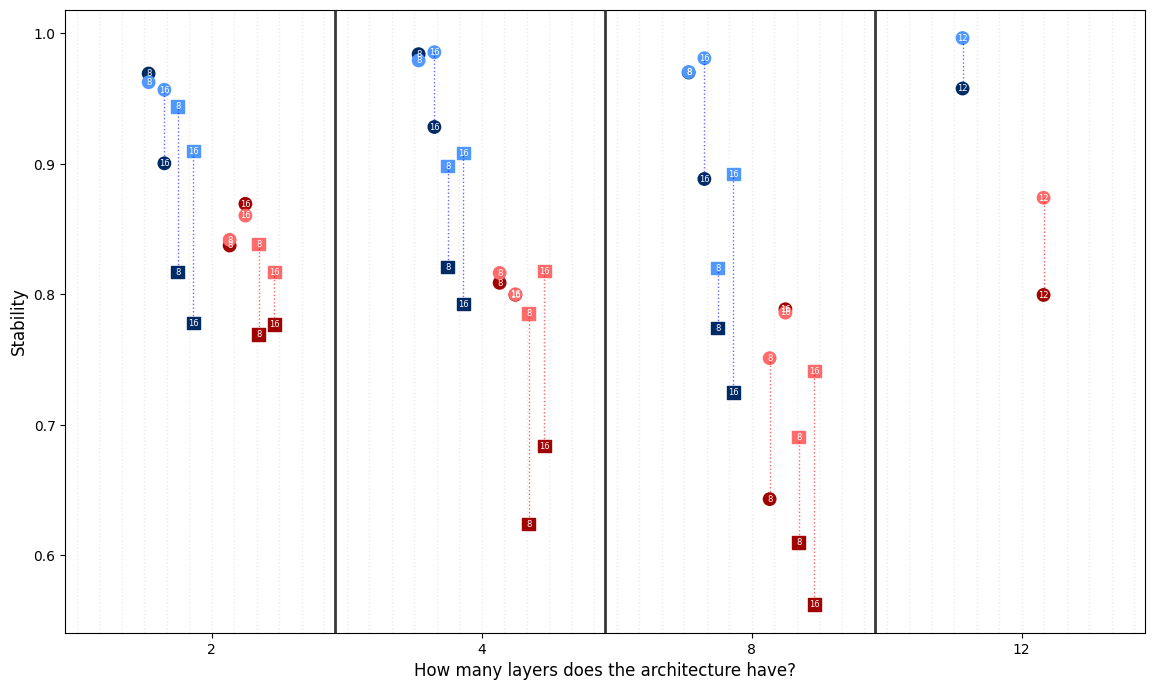

In [10]:
from matplotlib.lines import Line2D

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

def lighten_color(color, amount=0.5):
    try:
        c = mcolors.cnames[color]
    except Exception:
        c = color
    c = mcolors.to_rgb(c)
    return mcolors.to_hex([min(1, x + (1 - x) * amount) for x in c])

def darken_color(color, amount=0.3):
    try:
        c = mcolors.cnames[color]
    except Exception:
        c = color
    c = mcolors.to_rgb(c)
    return mcolors.to_hex([max(0, x * (1 - x)) for x in c])

# Explicit dark/light color choices
DARK_BLUE = "#002a64"
LIGHT_BLUE = "#5098fd"
DARK_RED = "#a00101"
LIGHT_RED = "#ff6a6a"

def get_shaded_color(color, wd):
    # color expected to be 'blue' or 'red' in this script
    c = color.lower()
    if c == 'blue':
        return LIGHT_BLUE if wd else DARK_BLUE
    if c == 'red':
        return LIGHT_RED if wd else DARK_RED
    # fallback to original behavior for other color names/hex values
    return lighten_color(color, amount=0.4) if wd else darken_color(color, amount=0.5)

# attn_only -> square, mlp -> circle
marker_shape_map = {True: 's', False: 'o'}
marker_displacement_shape = {'o': -0.01, 's': 0.01}

allowed_layers = [2, 4, 8, 12]

# Divide x-axis into 48 grid lines, 12 per layer
total_grid_lines = 48
segment_width = total_grid_lines // len(allowed_layers)  # 12
layer_positions = {layer: i * segment_width + segment_width / 2 for i, layer in enumerate(allowed_layers)}  # centers: 6,18,30,42

subset = df_minmax_layer[df_minmax_layer['type'] == 'avg_head_similarity']

vertical_jitter_value = 0.000  # kept but no longer used for vertical separation

# Build per-layer ordering of (num_heads, attn_only) combos so we can spread them horizontally
layer_group_map = {}
layer_group_counts = {}
for layer in allowed_layers:
    lg = (
        subset[subset['num_layers'] == layer][['num_heads', 'attn_only']]
        .drop_duplicates()
        .sort_values(['num_heads', 'attn_only'])
        .reset_index(drop=True)
    )
    mapping = {}
    for idx, row in lg.iterrows():
        mapping[(int(row['num_heads']), bool(row['attn_only']))] = int(idx)
    layer_group_map[layer] = mapping
    layer_group_counts[layer] = len(lg)

# legend handles for shapes (num inside indicates num_heads)
shape_handles = [
    Line2D([0], [0], marker='o', color='grey', linestyle='None', markersize=8, label='MLP (num=heads)'),
    Line2D([0], [0], marker='s', color='grey', linestyle='None', markersize=8, label='Attn only (num=heads)')
]

fig1, ax1 = plt.subplots(1, 1, figsize=(12, 7))

# 48 vertical grid lines across the x-axis
for pos in range(total_grid_lines):
    ax1.axvline(pos, color='gray', linestyle=':', linewidth=1, alpha=0.15)

# Solid bold separators between the 12-unit segments (dividing the plot for options 2,4,8,12)
# draw at the boundaries between segments (i.e. between 0-11, 12-23, 24-35, 36-47 -> boundaries at 12,24,36)
for i in range(1, len(allowed_layers)):
    boundary_x = i * segment_width - 0.5  # place between integer gridlines
    ax1.axvline(boundary_x, color='#222222', linestyle='-', linewidth=2.0, alpha=0.9, zorder=3)

# Offset the x-centers so max_value and min_value markers use different centers per layer
center_offset = segment_width * 0.15  # tweak if you want more/less separation
layer_positions_max = {l: c - center_offset for l, c in layer_positions.items()}
layer_positions_min = {l: c + center_offset for l, c in layer_positions.items()}

# containers to connect wd pairs
max_points = {}
min_points = {}

# spacing between different aligned sets within the same layer (tweakable)
group_spacing = 1.05  # in x-axis units; increase to create more gap between side-by-side sets

# plot all max (blue) points first using layer_positions_max
for num_heads in sorted(subset['num_heads'].unique()):
    for attn_only in [False, True]:
        sub_data = subset[(subset['num_heads'] == num_heads) & (subset['attn_only'] == attn_only)]
        if sub_data.empty:
            continue

        marker_shape = marker_shape_map[attn_only]
        displacement_scaled = marker_displacement_shape.get(marker_shape, 0) * segment_width

        # compute group indices and extra offsets so different (num_heads, attn_only) combos in the same layer don't overlap
        group_indices = [
            layer_group_map[int(l)].get((int(nh), bool(ao)), 0)
            for l, nh, ao in zip(sub_data['num_layers'], sub_data['num_heads'], sub_data['attn_only'])
        ]
        extra_offsets = []
        for l, gi in zip(sub_data['num_layers'], group_indices):
            count = max(1, layer_group_counts[int(l)])
            center_idx = (count - 1) / 2.0
            extra_offsets.append((gi - center_idx) * group_spacing)

        x_centers_max = sub_data['num_layers'].map(layer_positions_max)
        x_base_max = x_centers_max + displacement_scaled
        x_base_max = x_base_max + np.array(extra_offsets)  # apply per-row extra spacing

        wd_x_jitter = np.where(sub_data['num_heads'].values==8, 0.7, -0.7)
        x_vals_max = x_base_max + wd_x_jitter

        y_vals_max = sub_data['max_value'].values
        colors_max = [get_shaded_color('blue', wd) for wd in sub_data['wd']]

        ax1.scatter(x_vals_max, y_vals_max, s=80, marker=marker_shape, color=colors_max)
        for xv, yv, lv, wd_val in zip(x_vals_max, y_vals_max, sub_data['num_layers'], sub_data['wd']):
            ax1.text(xv, yv, str(int(num_heads)), ha='center', va='center', fontsize=6, color='white')
            max_points.setdefault((lv, num_heads, attn_only), []).append((wd_val, xv, yv))

# then plot all min (red) points using layer_positions_min
for num_heads in sorted(subset['num_heads'].unique()):
    for attn_only in [False, True]:
        sub_data = subset[(subset['num_heads'] == num_heads) & (subset['attn_only'] == attn_only)]
        if sub_data.empty:
            continue

        marker_shape = marker_shape_map[attn_only]
        displacement_scaled = marker_displacement_shape.get(marker_shape, 0) * segment_width

        # compute group indices and extra offsets so different (num_heads, attn_only) combos in the same layer don't overlap
        group_indices = [
            layer_group_map[int(l)].get((int(nh), bool(ao)), 0)
            for l, nh, ao in zip(sub_data['num_layers'], sub_data['num_heads'], sub_data['attn_only'])
        ]
        extra_offsets = []
        for l, gi in zip(sub_data['num_layers'], group_indices):
            count = max(1, layer_group_counts[int(l)])
            center_idx = (count - 1) / 2.0
            extra_offsets.append((gi - center_idx) * group_spacing)

        x_centers_min = sub_data['num_layers'].map(layer_positions_min)
        x_base_min = x_centers_min + displacement_scaled
        x_base_min = x_base_min + np.array(extra_offsets)  # apply per-row extra spacing

        wd_x_jitter = np.where(sub_data['num_heads'].values==8, 0.7, -0.7)
        x_vals_min = x_base_min + wd_x_jitter

        y_vals_min = sub_data['min_value'].values
        colors_min = [get_shaded_color('red', wd) for wd in sub_data['wd']]

        ax1.scatter(x_vals_min, y_vals_min, s=80, marker=marker_shape, color=colors_min)
        for xv, yv, lv, wd_val in zip(x_vals_min, y_vals_min, sub_data['num_layers'], sub_data['wd']):
            ax1.text(xv, yv, str(int(num_heads)), ha='center', va='center', fontsize=6, color='white')
            min_points.setdefault((lv, num_heads, attn_only), []).append((wd_val, xv, yv))

# connect wd pairs with dotted lines
for pts in max_points.values():
    if len(pts) == 2:
        pts_sorted = sorted(pts, key=lambda t: t[0])  # sort by wd
        ax1.plot([pts_sorted[0][1], pts_sorted[1][1]],
                 [pts_sorted[0][2], pts_sorted[1][2]],
                 linestyle=':', color='blue', alpha=0.6, linewidth=1)

for pts in min_points.values():
    if len(pts) == 2:
        pts_sorted = sorted(pts, key=lambda t: t[0])  # sort by wd
        ax1.plot([pts_sorted[0][1], pts_sorted[1][1]],
                 [pts_sorted[0][2], pts_sorted[1][2]],
                 linestyle=':', color='red', alpha=0.6, linewidth=1)

ax1.set_xlabel('How many layers does the architecture have?', fontsize=12)
ax1.set_ylabel('Stability', fontsize=12)
ax1.set_xlim(-0.5, total_grid_lines - 0.5)
ax1.set_xticks([layer_positions[l] for l in allowed_layers])
ax1.set_xticklabels(allowed_layers)

plt.tight_layout()
plt.subplots_adjust(left=0.08, right=0.98, top=0.97, bottom=0.08)
plt.show()


***
***

## Generate plot for: 2) Position of the most- and least-stable layer relative to architecture depth

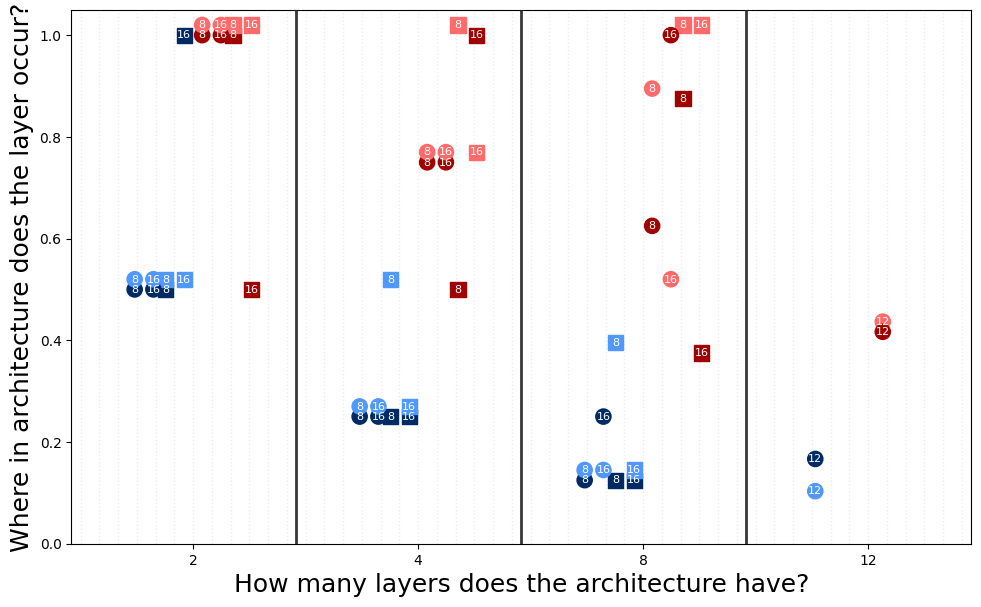

In [26]:
# ---- Second figure: Layer Ratio ----
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))

# 48 vertical grid lines
for pos in range(total_grid_lines):
    ax2.axvline(pos, color='gray', linestyle=':', linewidth=1, alpha=0.15)

# Bold separators between segments
for i in range(1, len(allowed_layers)):
    boundary_x = i * segment_width - 0.5
    ax2.axvline(boundary_x, color='#222222', linestyle='-', linewidth=2.0, alpha=0.9, zorder=3)

# Offset x-centers for max and min
center_offset = segment_width * 0.15
layer_positions_max_ratio = {l: c - center_offset for l, c in layer_positions.items()}
layer_positions_min_ratio = {l: c + center_offset for l, c in layer_positions.items()}

# Containers to connect wd pairs
max_points_ratio = {}
min_points_ratio = {}

# Increased marker size and text size
marker_size_ratio = 120
text_size_ratio = 8

# Plot max_length_ratio (blue) points
for num_heads in sorted(subset['num_heads'].unique()):
    for attn_only in [False, True]:
        sub_data = subset[(subset['num_heads'] == num_heads) & (subset['attn_only'] == attn_only)]
        if sub_data.empty:
            continue

        marker_shape = marker_shape_map[attn_only]
        displacement_scaled = marker_displacement_shape.get(marker_shape, 0) * segment_width

        # Compute group indices and extra offsets
        group_indices = [
            layer_group_map[int(l)].get((int(nh), bool(ao)), 0)
            for l, nh, ao in zip(sub_data['num_layers'], sub_data['num_heads'], sub_data['attn_only'])
        ]
        extra_offsets = []
        for l, gi in zip(sub_data['num_layers'], group_indices):
            count = max(1, layer_group_counts[int(l)])
            center_idx = (count - 1) / 2.0
            extra_offsets.append((gi - center_idx) * group_spacing)

        x_centers_max = sub_data['num_layers'].map(layer_positions_max_ratio)
        x_base_max = x_centers_max + displacement_scaled + np.array(extra_offsets)

        wd_x_jitter = np.where(sub_data['num_heads'].values==8, 0.9, -0.9)
        x_vals_max = x_base_max + wd_x_jitter

        wd_y_jitter = np.where(sub_data['wd'].values, 0.02, 0.00)
        y_vals_max = sub_data['max_length_ratio'].values + wd_y_jitter
        colors_max = [get_shaded_color('blue', wd) for wd in sub_data['wd']]

        ax2.scatter(x_vals_max, y_vals_max, s=marker_size_ratio, marker=marker_shape, color=colors_max)
        for xv, yv, lv, wd_val in zip(x_vals_max, y_vals_max, sub_data['num_layers'], sub_data['wd']):
            ax2.text(xv, yv, str(int(num_heads)), ha='center', va='center', fontsize=text_size_ratio, color='white')
            max_points_ratio.setdefault((lv, num_heads, attn_only), []).append((wd_val, xv, yv))

# Plot min_length_ratio (red) points
for num_heads in sorted(subset['num_heads'].unique()):
    for attn_only in [False, True]:
        sub_data = subset[(subset['num_heads'] == num_heads) & (subset['attn_only'] == attn_only)]
        if sub_data.empty:
            continue

        marker_shape = marker_shape_map[attn_only]
        displacement_scaled = marker_displacement_shape.get(marker_shape, 0) * segment_width

        # Compute group indices and extra offsets
        group_indices = [
            layer_group_map[int(l)].get((int(nh), bool(ao)), 0)
            for l, nh, ao in zip(sub_data['num_layers'], sub_data['num_heads'], sub_data['attn_only'])
        ]
        extra_offsets = []
        for l, gi in zip(sub_data['num_layers'], group_indices):
            count = max(1, layer_group_counts[int(l)])
            center_idx = (count - 1) / 2.0
            extra_offsets.append((gi - center_idx) * group_spacing)

        x_centers_min = sub_data['num_layers'].map(layer_positions_min_ratio)
        x_base_min = x_centers_min + displacement_scaled + np.array(extra_offsets)

        wd_x_jitter = np.where(sub_data['num_heads'].values==8, 0.9, -0.9)
        x_vals_min = x_base_min + wd_x_jitter

        wd_y_jitter = np.where(sub_data['wd'].values, 0.02, 0.00)
        y_vals_min = sub_data['min_length_ratio'].values + wd_y_jitter
        colors_min = [get_shaded_color('red', wd) for wd in sub_data['wd']]

        ax2.scatter(x_vals_min, y_vals_min, s=marker_size_ratio, marker=marker_shape, color=colors_min)
        for xv, yv, lv, wd_val in zip(x_vals_min, y_vals_min, sub_data['num_layers'], sub_data['wd']):
            ax2.text(xv, yv, str(int(num_heads)), ha='center', va='center', fontsize=text_size_ratio, color='white')
            min_points_ratio.setdefault((lv, num_heads, attn_only), []).append((wd_val, xv, yv))


# Color legend for layer ratio values
color_handles = [
    mpatches.Patch(color=get_shaded_color('red', True), label='Min stability (AdamW)'),
    mpatches.Patch(color=get_shaded_color('red', False), label='Min stability (Adam)'),
    mpatches.Patch(color=get_shaded_color('blue', True), label='Max stability  (AdamW)'),
    mpatches.Patch(color=get_shaded_color('blue', False), label='Max stability (Adam)')
]

o = Line2D([0],[0], marker='o', linestyle='None',
                color='grey', markerfacecolor='#48475d', markersize=10)

o_txt = Line2D([0],[0], marker=r'$\mathregular{8}$', linestyle='None',
             color='white', markersize=8)

s = Line2D([0],[0], marker='s', linestyle='None',
                color='grey', markerfacecolor='#48475d', markersize=10)

s_txt = Line2D([0],[0], marker=r'$\mathregular{16}$', linestyle='None',
             color='white', markersize=8)

circle = (o, o_txt)
square = (s, s_txt)

# legend1 = ax2.legend([circle, square], ['MLP', 'Attention only'],
#           handler_map={tuple: HandlerTuple(ndivide=1, pad=0)}, bbox_to_anchor=(1.02, 0.25), loc='upper left', title='Architecture', fontsize=10)

# legend2 = ax2.legend(handles=color_handles, bbox_to_anchor=(1.02, 1), loc='upper left', title='Value type', fontsize=8)

# ax2.add_artist(legend1)

ax2.set_xlabel('How many layers does the architecture have?', fontsize=18)
ax2.set_ylabel('Where in architecture does the layer occur?', fontsize=18)
ax2.set_xlim(-0.5, total_grid_lines - 0.5)
ax2.set_xticks([layer_positions[l] for l in allowed_layers])
ax2.set_xticklabels(allowed_layers)
ax2.set_ylim(0, 1.05)

ax2.tick_params(axis='x', labelsize=10)
ax2.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.subplots_adjust(left=0.08, right=0.98, top=0.97, bottom=0.08)
plt.show()


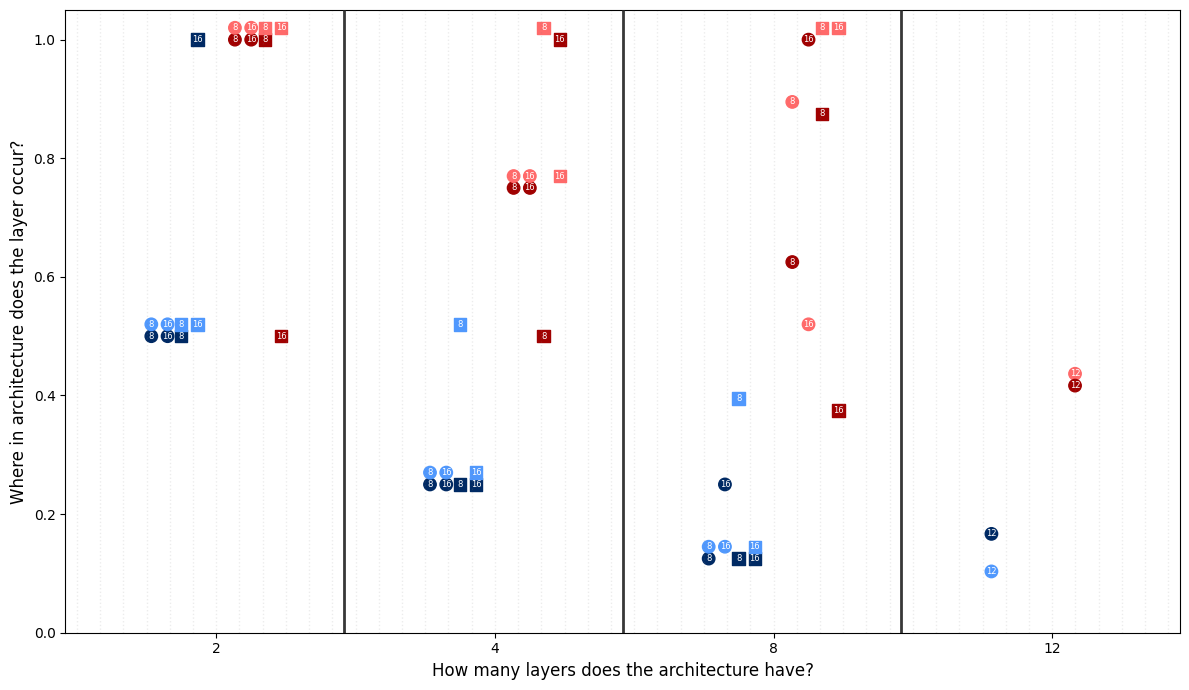

In [12]:
# ---- Second figure: Layer Ratio ----
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 7))

# 48 vertical grid lines
for pos in range(total_grid_lines):
    ax2.axvline(pos, color='gray', linestyle=':', linewidth=1, alpha=0.15)

# Bold separators between segments
for i in range(1, len(allowed_layers)):
    boundary_x = i * segment_width - 0.5
    ax2.axvline(boundary_x, color='#222222', linestyle='-', linewidth=2.0, alpha=0.9, zorder=3)

# Offset x-centers for max and min
center_offset = segment_width * 0.15
layer_positions_max_ratio = {l: c - center_offset for l, c in layer_positions.items()}
layer_positions_min_ratio = {l: c + center_offset for l, c in layer_positions.items()}

# Containers to connect wd pairs
max_points_ratio = {}
min_points_ratio = {}

# Plot max_length_ratio (blue) points
for num_heads in sorted(subset['num_heads'].unique()):
    for attn_only in [False, True]:
        sub_data = subset[(subset['num_heads'] == num_heads) & (subset['attn_only'] == attn_only)]
        if sub_data.empty:
            continue

        marker_shape = marker_shape_map[attn_only]
        displacement_scaled = marker_displacement_shape.get(marker_shape, 0) * segment_width

        # Compute group indices and extra offsets
        group_indices = [
            layer_group_map[int(l)].get((int(nh), bool(ao)), 0)
            for l, nh, ao in zip(sub_data['num_layers'], sub_data['num_heads'], sub_data['attn_only'])
        ]
        extra_offsets = []
        for l, gi in zip(sub_data['num_layers'], group_indices):
            count = max(1, layer_group_counts[int(l)])
            center_idx = (count - 1) / 2.0
            extra_offsets.append((gi - center_idx) * group_spacing)

        x_centers_max = sub_data['num_layers'].map(layer_positions_max_ratio)
        x_base_max = x_centers_max + displacement_scaled + np.array(extra_offsets)

        wd_x_jitter = np.where(sub_data['num_heads'].values==8, 0.7, -0.7)
        x_vals_max = x_base_max + wd_x_jitter

        wd_y_jitter = np.where(sub_data['wd'].values, 0.02, 0.00)
        y_vals_max = sub_data['max_length_ratio'].values + wd_y_jitter
        colors_max = [get_shaded_color('blue', wd) for wd in sub_data['wd']]

        ax2.scatter(x_vals_max, y_vals_max, s=80, marker=marker_shape, color=colors_max)
        for xv, yv, lv, wd_val in zip(x_vals_max, y_vals_max, sub_data['num_layers'], sub_data['wd']):
            ax2.text(xv, yv, str(int(num_heads)), ha='center', va='center', fontsize=6, color='white')
            max_points_ratio.setdefault((lv, num_heads, attn_only), []).append((wd_val, xv, yv))

# Plot min_length_ratio (red) points
for num_heads in sorted(subset['num_heads'].unique()):
    for attn_only in [False, True]:
        sub_data = subset[(subset['num_heads'] == num_heads) & (subset['attn_only'] == attn_only)]
        if sub_data.empty:
            continue

        marker_shape = marker_shape_map[attn_only]
        displacement_scaled = marker_displacement_shape.get(marker_shape, 0) * segment_width

        # Compute group indices and extra offsets
        group_indices = [
            layer_group_map[int(l)].get((int(nh), bool(ao)), 0)
            for l, nh, ao in zip(sub_data['num_layers'], sub_data['num_heads'], sub_data['attn_only'])
        ]
        extra_offsets = []
        for l, gi in zip(sub_data['num_layers'], group_indices):
            count = max(1, layer_group_counts[int(l)])
            center_idx = (count - 1) / 2.0
            extra_offsets.append((gi - center_idx) * group_spacing)

        x_centers_min = sub_data['num_layers'].map(layer_positions_min_ratio)
        x_base_min = x_centers_min + displacement_scaled + np.array(extra_offsets)

        wd_x_jitter = np.where(sub_data['num_heads'].values==8, 0.7, -0.7)
        x_vals_min = x_base_min + wd_x_jitter

        wd_y_jitter = np.where(sub_data['wd'].values, 0.02, 0.00)
        y_vals_min = sub_data['min_length_ratio'].values + wd_y_jitter
        colors_min = [get_shaded_color('red', wd) for wd in sub_data['wd']]

        ax2.scatter(x_vals_min, y_vals_min, s=80, marker=marker_shape, color=colors_min)
        for xv, yv, lv, wd_val in zip(x_vals_min, y_vals_min, sub_data['num_layers'], sub_data['wd']):
            ax2.text(xv, yv, str(int(num_heads)), ha='center', va='center', fontsize=6, color='white')
            min_points_ratio.setdefault((lv, num_heads, attn_only), []).append((wd_val, xv, yv))

ax2.set_xlabel('How many layers does the architecture have?', fontsize=12)
ax2.set_ylabel('Where in architecture does the layer occur?', fontsize=12)
ax2.set_xlim(-0.5, total_grid_lines - 0.5)
ax2.set_xticks([layer_positions[l] for l in allowed_layers])
ax2.set_xticklabels(allowed_layers)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


***
***